# Python lambda 匿名函数详解
lambda 函数（匿名函数）是 Python 中创建简单、一次性、单行函数的便捷方式，核心特点是「匿名」（无正式函数名）、「简洁」（仅一行表达式），常与高阶函数（如 map/filter/sorted）配合使用。下面从核心概念、语法、使用场景、注意事项等维度全面讲解。
## 一、核心概念
lambda 函数本质是「简化版的函数」，用于替代逻辑简单、仅需一次性使用的普通函数（def 定义的函数）。它没有函数名（匿名），仅包含参数列表和单个表达式，表达式的结果就是函数的返回值（无需写 return）。
## 二、lambda 基本语法
lambda 参数列表: 表达式
- 参数列表：与普通函数一致，可接收 0 个、1 个或多个参数（如 x、x,y、x,y=10）；
- 表达式：只能有一个（不能是循环、if 语句块等复杂逻辑），表达式的计算结果会自动返回（无需 return）；
- 返回值：表达式的结果就是 lambda 函数的返回值。
### 示例1:基础lambda函数

In [5]:
(lambda x:x*2)(5),(lambda x,y:x+y)(3,4),(lambda: "hello")(),(lambda x,y=10:x+y)(5)


(10, 7, 'hello', 15)

In [6]:
# 1. 直接调用 lambda 函数（一次性使用）
print((lambda x: x * 2)(5))  # 输出：10

# 2. 赋值给变量（复用 lambda 函数，等价于普通函数）
double = lambda x: x * 2
print(double(6))  # 输出：12

# 3. 多参数 lambda
add = lambda x, y: x + y
print(add(3, 4))  # 输出：7

10
12
7


### 示例2:lambda中使用三元表达式（处理简单条件）
lambda 不支持 if-else 语句块，但支持三元表达式（唯一的条件处理方式）：

In [7]:
# 示例：判断数字正负
check_num = lambda x: "正数" if x > 0 else "负数/零"
print(check_num(5))   # 输出：正数
print(check_num(-3))  # 输出：负数/零
print(check_num(0))   # 输出：负数/零

# 示例：两数取大
max_num = lambda x, y: x if x > y else y
print(max_num(10, 20))  # 输出：20

正数
负数/零
负数/零
20


## 三、lambda的核心使用场景
lambda 本身无优势，但其简洁性使其成为高阶函数的「最佳搭档」—— 作为 map/filter/sorted 等函数的参数，替代临时定义的普通函数。
### 场景1:与map()配合（批量处理可迭代对象）
map(func, 可迭代对象) 对每个元素执行 func，lambda 可简化 func 的定义：

In [8]:
# 需求：将列表中每个数字平方
nums = [1, 2, 3, 4]

# 普通函数方式（繁琐）
def square(x):
    return x * x
result1 = list(map(square, nums))

# lambda 方式（简洁）
result2 = list(map(lambda x: x * x, nums))

print(result1)  # 输出：[1, 4, 9, 16]
print(result2)  # 输出：[1, 4, 9, 16]

[1, 4, 9, 16]
[1, 4, 9, 16]


### 场景2：与filter()配合（过滤可迭代对象）
filter(func, 可迭代对象) 按 func 的条件过滤元素（func 返回布尔值）：

In [9]:
# 需求：筛选列表中的偶数
nums = [1, 2, 3, 4, 5, 6]

# 普通函数方式
def is_even(x):
    return x % 2 == 0
result1 = list(filter(is_even, nums))

# lambda 方式
result2 = list(filter(lambda x: x % 2 == 0, nums))

print(result1)  # 输出：[2, 4, 6]
print(result2)  # 输出：[2, 4, 6]

[2, 4, 6]
[2, 4, 6]


### 场景3:与sorted()配合（自定义排序规则）
sorted(可迭代对象, key=func) 中 key 参数接收函数，用于指定排序依据，lambda 是最优选择：

In [10]:
# 示例 1：按列表元素的绝对值排序
nums = [-3, 1, -2, 5]
# key=lambda x: abs(x) → 按绝对值排序
sorted_nums = sorted(nums, key=lambda x: abs(x))
print(sorted_nums)  # 输出：[1, -2, -3, 5]

# 示例 2：按字典的指定键排序
students = [
    {"name": "张三", "age": 25},
    {"name": "李四", "age": 20},
    {"name": "王五", "age": 22}
]
# key=lambda x: x["age"] → 按 age 升序排序
sorted_students = sorted(students, key=lambda x: x["age"])
print(sorted_students)
# 输出：[{'name': '李四', 'age': 20}, {'name': '王五', 'age': 22}, {'name': '张三', 'age': 25}]

[1, -2, -3, 5]
[{'name': '李四', 'age': 20}, {'name': '王五', 'age': 22}, {'name': '张三', 'age': 25}]


### 场景4:作为函数返回值（结合闭包）
lambda 可作为高阶函数的返回值，简化闭包的定义：

In [11]:
# 需求：生成加法器（固定加数）
def create_adder(add_num):
    # 用 lambda 替代内层函数，更简洁
    return lambda x: x + add_num

add5 = create_adder(5)
print(add5(10))  # 输出：15

add10 = create_adder(10)
print(add10(10))  # 输出：20

15
20


## 四、lambda的注意事项
1. 仅适用于简单逻辑：lambda 只能包含一个表达式，不支持循环（for/while）、try-except、if-else 语句块等复杂逻辑，复杂逻辑请用 def 定义普通函数；
2. 可读性优先：若 lambda 表达式过长（如嵌套三元表达式），建议改用普通函数，避免代码晦涩；
3. 不要过度赋值：虽然可以将 lambda 赋值给变量（如 double = lambda x: x*2），但这种场景直接用 def 更清晰（代码可注释、可调试）；
4. 无函数名，调试稍复杂：lambda 函数的 \_\_name__ 属性为 <lambda>，报错时定位不如普通函数直观。

## 五、lambda vs 普通函数
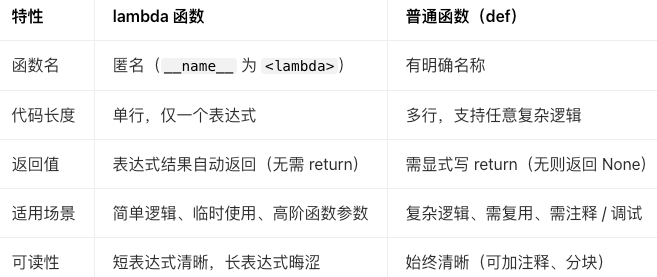